# Análisis de patrones de compra de clientes de Starbucks

Este proyecto analiza un dataset de **100.000 transacciones simuladas de Starbucks**, con el objetivo de entender y predecir el comportamiento de los clientes.  
Incluye:

- Exploración de datos (EDA) sobre regiones, género y canales de pedido.  
- Análisis de satisfacción promedio según canal y tamaño del carrito.  
- Estudio del gasto en función del tamaño del carrito.  
- Entrenamiento de un modelo de **Random Forest Regressor** para predecir el gasto total, alcanzando un desempeño excelente (R²=0.97, RMSE=1.02).  
- Interpretación de variables clave: **cart_size**, **canal Mobile App** y **personalizaciones** como principales impulsores del gasto.  

El análisis se realiza con **Python, pandas, NumPy, scikit-learn, Seaborn y Matplotlib**, y se complementa con funciones de visualización y documentación en Markdown.

In [1]:
# Librerias principales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from data_utils import missing_data_report
from visualizaciones import plot_category_values

In [2]:
# Configuracion visual
sns.set(style="whitegrid")

In [3]:
# para ver los graficos dentro del notebook
df = pd.read_csv('../data/starbucks_customer_ordering_patterns.csv')
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  str    
 1   order_id               100000 non-null  str    
 2   order_date             100000 non-null  str    
 3   order_time             100000 non-null  str    
 4   day_of_week            100000 non-null  str    
 5   order_channel          100000 non-null  str    
 6   store_id               100000 non-null  str    
 7   store_location_type    100000 non-null  str    
 8   region                 100000 non-null  str    
 9   customer_age_group     100000 non-null  str    
 10  customer_gender        100000 non-null  str    
 11  is_rewards_member      100000 non-null  bool   
 12  cart_size              100000 non-null  int64  
 13  num_customizations     100000 non-null  int64  
 14  total_spend            100000 non-null  float64


## Distribución inicial de clientes

Para comenzar, analizamos cómo se distribuyen los registros por región y género.  
Esto nos da contexto sobre la composición del dataset y posibles sesgos.

**Conclusión:**  
La distribución por género está relativamente balanceada entre mujeres (45,306) y hombres (44,767).  
Además, se registran 5,058 clientes no binarios y 4,869 que prefirieron no declarar su género.  
Esto refleja diversidad en la base de clientes y aporta contexto para interpretar los resultados posteriores.

In [4]:
# Cuento la cantidad de registros por región y por género
df['customer_gender'].value_counts()

customer_gender
Female               45306
Male                 44767
Non-binary            5058
Prefer not to say     4869
Name: count, dtype: int64

**Conclusión:**  
La distribución por región muestra que la mayor cantidad de clientes proviene del **West (22,608)**, seguido por **Southeast (20,223)** y **Southwest (19,663)**.  
Las regiones **Midwest (19,470)** y **Northeast (18,036)** tienen una participación algo menor, pero igualmente significativa.  

Esto indica que el dataset está dominado por clientes del oeste y del sur de Estados Unidos, lo cual puede influir en los patrones de compra observados y debe tenerse en cuenta al interpretar los resultados.

In [5]:
# Cuento la cantidad de registros por región
df['region'].value_counts()

region
West         22608
Southeast    20223
Southwest    19663
Midwest      19470
Northeast    18036
Name: count, dtype: int64

## Selección de columnas relevantes

Para simplificar el análisis, se seleccionaron únicamente las columnas más importantes del dataset:  
- Identificadores de cliente y orden (`customer_id`, `order_id`)  
- Información de la tienda (`store_id`, `store_location_type`, `region`)  
- Datos del cliente (`customer_gender`)  
- Variables de interés para el análisis (`total_spend`, `drink_category`, `customer_satisfaction`)  

**Conclusión:**  
Con esta selección, reducimos la complejidad del dataset y nos enfocamos en las variables que realmente aportan valor al análisis.  
Esto permite trabajar de manera más ordenada y facilita la interpretación de los resultados en las siguientes etapas.

In [6]:
# Filtro solo las columnas importantes
cols_relevantes = [
    'customer_id', 'order_id', 'store_id',
    'store_location_type', 'region', 'customer_gender',
    'total_spend', 'drink_category', 'customer_satisfaction'
]

# df = select_columns(df, cols_relevantes)
df.head()

,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3


## Información general del DataFrame

El dataset contiene **100,000 registros** y **20 columnas**.  
Algunas observaciones clave:

- No hay valores nulos: todas las columnas tienen 100,000 registros completos.  
- Los tipos de datos están bien definidos:  
  - Variables categóricas como `region`, `customer_gender`, `order_channel` son de tipo `str`.  
  - Variables numéricas como `cart_size`, `num_customizations`, `total_spend`, `fulfillment_time_min`, `customer_satisfaction` están en `int64` o `float64`.  
  - Variables booleanas (`is_rewards_member`, `has_food_item`, `order_ahead`) permiten análisis de comportamiento.  
- El tamaño total del dataset es de aproximadamente **13.3 MB**, lo que lo hace manejable para análisis en memoria.

**Conclusión:**  
El dataset está completo y bien estructurado, sin valores faltantes. Esto facilita el análisis exploratorio y asegura que las métricas calculadas serán representativas. Además, la variedad de tipos de datos (categóricos, numéricos y booleanos) permite realizar un análisis integral de los patrones de compra y satisfacción de los clientes.

In [7]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  str    
 1   order_id               100000 non-null  str    
 2   order_date             100000 non-null  str    
 3   order_time             100000 non-null  str    
 4   day_of_week            100000 non-null  str    
 5   order_channel          100000 non-null  str    
 6   store_id               100000 non-null  str    
 7   store_location_type    100000 non-null  str    
 8   region                 100000 non-null  str    
 9   customer_age_group     100000 non-null  str    
 10  customer_gender        100000 non-null  str    
 11  is_rewards_member      100000 non-null  bool   
 12  cart_size              100000 non-null  int64  
 13  num_customizations     100000 non-null  int64  
 14  total_spend            100000 non-null  float64


In [8]:
# Muestro los nombres de todas las columnas del DataFrame
df.columns

Index(['customer_id', 'order_id', 'order_date', 'order_time', 'day_of_week',
       'order_channel', 'store_id', 'store_location_type', 'region',
       'customer_age_group', 'customer_gender', 'is_rewards_member',
       'cart_size', 'num_customizations', 'total_spend',
       'fulfillment_time_min', 'drink_category', 'has_food_item',
       'order_ahead', 'customer_satisfaction'],
      dtype='str')

## Reporte de datos faltantes

Se verificó la presencia de valores nulos en el dataset.  
El resultado muestra que **no se encontraron columnas con datos faltantes**.

**Conclusión:**  
El dataset está completo y no requiere imputación ni limpieza de valores nulos.  
Esto facilita el análisis y asegura que las métricas calculadas serán representativas sin necesidad de preprocesamiento adicional.

In [9]:
# Utilizo una funcion para un reporte de datos faltantes en el DataFrame, mostrando columnas
# con valores nulos (según el threshold)
# y opcionalmente un grafico
missing_data_report(df, threshold=1, plot=True)

 No se encontraron columnas con datos faltantes.


Series([], dtype: float64)

## Verificación de duplicados en IDs

Se revisaron los identificadores principales del dataset:

- `order_id`: no se encontraron duplicados, lo que asegura que cada pedido está registrado de manera única.  
- `customer_id`: se encontraron **85,012 duplicados**, lo que indica que un mismo cliente puede tener múltiples pedidos registrados.  
- `store_id`: se encontraron **99,500 duplicados**, reflejando que las tiendas aparecen repetidamente porque concentran múltiples órdenes.


**Conclusión:**  
Los identificadores de órdenes son únicos y garantizan la integridad de cada transacción.  
En cambio, los duplicados en `customer_id` y `store_id` son esperables y naturales: los clientes realizan más de un pedido y las tiendas atienden múltiples órdenes.  
Esto confirma que el dataset refleja relaciones uno-a-muchos entre clientes, tiendas y pedidos, lo cual es consistente con el contexto de ventas de Starbucks.

In [10]:
# Cuento la cantidad de IDs de orden duplicados en el DataFrame
df['order_id'].duplicated().sum()

np.int64(0)

In [11]:
# Cuento la cantidad de IDs de clientes
df['customer_id'].duplicated().sum()

np.int64(85012)

In [12]:
# Cuento la cantidad de IDs de tiendas duplicados
df['store_id'].duplicated().sum()

np.int64(99500)

## Duplicados por combinación de cliente y timestamp

Se verificó si un mismo cliente aparece más de una vez con el mismo `order_date` y `order_time`.  
El resultado fue **0 duplicados**.

**Conclusión:**  
No existen registros repetidos con el mismo cliente y timestamp exacto, lo que asegura la consistencia temporal de los datos.

In [13]:
#Verifico duplicados por combinacion
#cuantas veces el mismo cliente aparece con el mismo timestamp exacto
df.duplicated(subset=['customer_id', 'order_date', 'order_time']).sum()

np.int64(0)

## Eliminación de duplicados por ID de orden

Se eliminaron posibles duplicados en la columna `order_id`.  
El resultado confirmó que no había duplicados.

**Conclusión:**  
Cada orden está registrada de manera única, garantizando la integridad de las transacciones.

In [14]:
# Eliminar duplicados por order_id
df = df.drop_duplicates(subset='order_id')

## Estadísticas descriptivas del gasto total

El análisis de la columna `total_spend` muestra:

- Promedio: **14.87**  
- Desvío estándar: **5.51**  
- Mínimo: **3.51**  
- Máximo: **40.31**  
- Percentiles:  
  - 25%: **10.84**  
  - 50% (mediana): **14.17**  
  - 75%: **18.18**

**Conclusión:**  
El gasto promedio por pedido es de aproximadamente **15 dólares**, con una variabilidad moderada.  
La mayoría de los pedidos se concentran entre **11 y 18 dólares**, mientras que los extremos muestran la amplitud de gasto posible en Starbucks.

In [15]:
# Muestro estadisticas descriptivas del gasto total (media, min, max, etc.)
df['total_spend'].describe()

count    100000.000000
mean         14.866771
std           5.506800
min           3.510000
25%          10.837500
50%          14.170000
75%          18.180000
max          40.310000
Name: total_spend, dtype: float64

## Distribución del gasto total (Boxplot)

El boxplot muestra cómo se distribuye el gasto total por pedido en Starbucks:

- La **caja central** representa el rango intercuartílico (IQR), es decir, el 50% de los pedidos que se concentran entre aproximadamente **10.8 y 18.2 dólares**.  
- La **línea dentro de la caja** indica la mediana, cercana a **14.2 dólares**, lo que confirma que la mayoría de los pedidos rondan ese valor.  
- Los **bigotes** se extienden hasta los valores mínimos y máximos dentro de 1.5 veces el IQR, mostrando la dispersión normal de los datos.  
- Los **puntos fuera de los bigotes** representan pedidos atípicos (outliers), en este caso algunos superiores a **30-40 dólares**, que corresponden a compras grandes o poco frecuentes.

**Conclusión:**  
El gasto total por pedido tiene una distribución bastante estable, con la mayoría de los clientes gastando entre **11 y 18 dólares**. Los valores extremos son pocos y plausibles, reflejando pedidos excepcionales de mayor monto. Esto confirma que el comportamiento de gasto es consistente, aunque existen casos aislados de consumo elevado.

<Axes: xlabel='total_spend'>

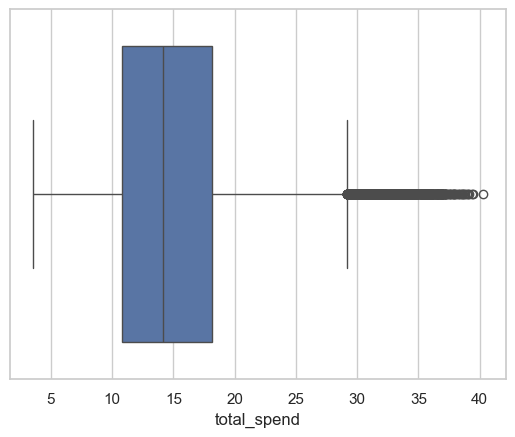

In [16]:
# Muestro un boxplot del gasto total para visualizar la distribucion y detectar outliers
sns.boxplot(x=df['total_spend'])

In [17]:
#Guardo el dataset original
df_original = df.copy()

## Detección de outliers en el gasto total (IQR)

El análisis con el método del **Rango Intercuartílico (IQR)** identificó valores extremos en el gasto total:

- Se encontraron **1415 pedidos** fuera de los límites establecidos.  
- Esto representa aproximadamente **1.42% del total de registros**.  
- Los outliers se concentran en el extremo superior, con gastos mayores a ~29 dólares.

**Conclusión:**  
La proporción de outliers es baja, lo que indica que la gran mayoría de los pedidos se mantiene dentro de un rango de gasto consistente.  
Los valores extremos corresponden a compras grandes o poco frecuentes, más que a errores en los datos. Por lo tanto, conviene analizarlos como casos especiales de consumo elevado, pero no es necesario eliminarlos ya que reflejan comportamientos reales de clientes.

In [18]:
#Calculo IQR
#Defino limites inferior y superior
Q1 = df['total_spend'].quantile(0.25)
Q3 = df['total_spend'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['total_spend'] < lower_bound) | 
    (df['total_spend'] > upper_bound)
]

print(f"Outliers en total_spend: {len(outliers)} pedidos ({len(outliers)/len(df)*100:.2f}%)")

Outliers en total_spend: 1415 pedidos (1.42%)


# Estadísticas de outliers

Se presentan estadísticas descriptivas del subconjunto de **outliers**, incluyendo tamaño del carrito, personalizaciones, gasto total, tiempo de cumplimiento y satisfacción del cliente.  
Este análisis permite entender la distribución y características extremas de los datos.

In [19]:
# Muestro estadisticas descriptivas del conjunto de outliers
outliers.describe()

,cart_size,num_customizations,total_spend,fulfillment_time_min,customer_satisfaction
count,1415.000000,1415.000000,1415.000000,1415.000000,1415.000000
mean,8.513781,3.369611,31.759110,4.552933,3.866431
std,0.956435,1.686474,2.178626,1.255265,1.126935
min,6.000000,0.000000,29.200000,1.000000,1.000000
25%,8.000000,2.000000,30.010000,3.700000,3.000000
50%,8.000000,3.000000,31.200000,4.500000,4.000000
75%,9.000000,4.000000,32.975000,5.400000,5.000000
max,10.000000,8.000000,40.310000,9.100000,5.000000


## Análisis de los outliers en el gasto total

Se calcularon estadísticas descriptivas para los pedidos identificados como outliers en `total_spend`:

- Promedio de gasto: **31.76 dólares**, más del doble del promedio general (~14.87).  
- Rango: entre **29.2 y 40.3 dólares**.  
- Tamaño de carrito: típicamente entre **8 y 10 ítems**, mayor que el promedio del dataset.  
- Personalizaciones: entre **2 y 8**, lo que indica pedidos más complejos.  
- Satisfacción del cliente: promedio de **3.87**, con valores que llegan hasta 5.

**Conclusión:**  
Los outliers corresponden a pedidos grandes y personalizados, con un gasto significativamente superior al promedio.  
Lejos de ser errores, reflejan un segmento de clientes que realizan compras más elaboradas y costosas, manteniendo además un nivel de satisfacción relativamente alto.

In [20]:
# Calculo el promedio del gasto total en todo el dataset y en los outliers
df['total_spend'].mean()
outliers['total_spend'].mean()

np.float64(31.759109540636043)

## Histograma del gasto total

El histograma muestra la frecuencia de los pedidos según el monto gastado:

- La mayor concentración de pedidos se encuentra entre **5 y 20 dólares**, con un pico claro alrededor de **13-14 dólares**.  
- La distribución es **ligeramente sesgada hacia la derecha**, lo que significa que existen algunos pedidos con gastos más altos que extienden la cola de la distribución.  
- Los valores extremos (superiores a 30 dólares) aparecen con baja frecuencia, confirmando lo observado en el boxplot y en la detección de outliers.  
- La forma general es consistente con un comportamiento de consumo estable, donde la mayoría de los clientes gasta en un rango moderado y solo unos pocos realizan compras grandes.

**Conclusión:**  
El histograma confirma que el gasto promedio por pedido se concentra en torno a los **15 dólares**, con una distribución relativamente simétrica pero con una cola hacia valores altos.  
Esto refleja un patrón de consumo típico: la mayoría de los clientes realiza compras regulares de bajo a mediano monto, mientras que un pequeño grupo realiza pedidos más grandes y costosos.

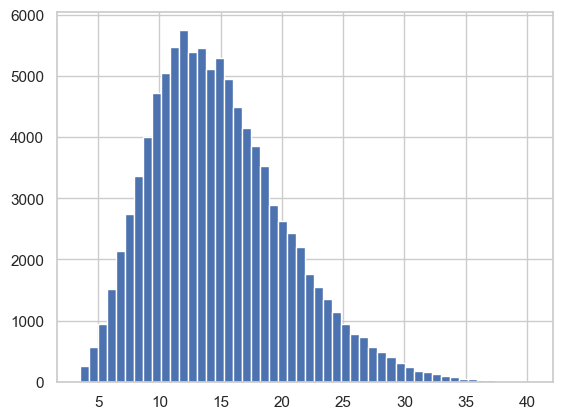

In [21]:
# Muestro un histograma del gasto total para visualizar su distribucion
df['total_spend'].hist(bins=50)
plt.show()

## Estadísticas descriptivas del tiempo de cumplimiento (en minutos)

El análisis de la columna `fulfillment_time_min` muestra:

- Promedio: **4.55 minutos**  
- Desvío estándar: **1.55 minutos**  
- Mínimo: **1 minuto**  
- Máximo: **11.2 minutos**  
- Percentiles:  
  - 25%: **3.4 minutos**  
  - 50% (mediana): **4.4 minutos**  
  - 75%: **5.5 minutos**

**Conclusión:**  
El tiempo de cumplimiento promedio es de alrededor de **4 a 5 minutos**, lo que refleja un servicio relativamente rápido y consistente.  
La mayoría de los pedidos se completan en menos de **6 minutos**, aunque existen casos aislados que superan los **10 minutos**, posiblemente asociados a pedidos más grandes o situaciones excepcionales.  
La baja variabilidad indica que el proceso de atención es estable y eficiente, con tiempos de espera razonables para los clientes.

In [22]:
# Muestra estadísticas descriptivas del tiempo de cumplimiento (en minutos)
df['fulfillment_time_min'].describe()

count    100000.000000
mean          4.546080
std           1.550269
min           1.000000
25%           3.400000
50%           4.400000
75%           5.500000
max          11.200000
Name: fulfillment_time_min, dtype: float64

## Detección de outliers en el tiempo de cumplimiento

Se aplicó el método del **Rango Intercuartílico (IQR)** para identificar pedidos con tiempos de cumplimiento atípicamente altos:

- Se encontraron **811 pedidos** fuera del límite superior.  
- Esto representa aproximadamente **0.81% del total de registros**.  
- Los outliers corresponden a tiempos de cumplimiento superiores a lo esperado (más de ~8 minutos).

**Conclusión:**  
La proporción de outliers es muy baja, lo que confirma que el proceso de atención es estable y eficiente en la mayoría de los casos.  
Los pedidos con tiempos elevados son excepcionales y probablemente se relacionen con situaciones específicas (pedidos grandes, alta personalización o condiciones operativas puntuales).  
Estos casos conviene analizarlos por separado para identificar oportunidades de mejora en la logística y atención.

In [23]:
# Calculo los cuartiles e IQR para detectar outliers en el tiempo de cumplimiento
# Defino el limite superior para considerar outliers
# Filtra los pedidos con tiempos atipicamente altos
# Cuenta y muestra cuántos outliers hay y su proporción
Q1 = df['fulfillment_time_min'].quantile(0.25)
Q3 = df['fulfillment_time_min'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers_time = df[df['fulfillment_time_min'] > upper_bound]
len(outliers_time)
print(f"Outliers en fulfillment_time_min: {len(outliers_time)} pedidos ({len(outliers_time)/len(df)*100:.2f}%)")

Outliers en fulfillment_time_min: 811 pedidos (0.81%)


## Relación entre satisfacción del cliente, tiempo de cumplimiento y gasto total

Se calcularon promedios de dos variables según el nivel de satisfacción del cliente:

### Tiempo de cumplimiento promedio
- Satisfacción 1: **4.82 min**
- Satisfacción 2: **4.69 min**
- Satisfacción 3: **4.56 min**
- Satisfacción 4: **4.44 min**
- Satisfacción 5: **4.55 min**

**Interpretación:**  
Los tiempos de cumplimiento tienden a ser más bajos en niveles altos de satisfacción (especialmente en nivel 4).  
Aunque el nivel 5 muestra un ligero aumento, la diferencia es mínima, lo que indica que la rapidez en la atención influye en la percepción positiva del cliente.

In [24]:
# Calculo el tiempo promedio de cumplimiento para cada nivel de satisfacción del cliente
df.groupby('customer_satisfaction')['fulfillment_time_min'].mean()

customer_satisfaction
1    4.824960
2    4.689343
3    4.560081
4    4.440253
5    4.547466
Name: fulfillment_time_min, dtype: float64

### Gasto promedio por nivel de satisfacción
- Satisfacción 1: **14.21 dólares**
- Satisfacción 2: **14.55 dólares**
- Satisfacción 3: **14.43 dólares**
- Satisfacción 4: **15.04 dólares**
- Satisfacción 5: **15.38 dólares**

**Interpretación:**  
Existe una relación positiva entre gasto y satisfacción: los clientes más satisfechos tienden a gastar más.  
La diferencia entre niveles bajos y altos es de más de **1 dólar por pedido**, lo que sugiere que la experiencia influye directamente en el consumo.

---

**Conclusión general:**  
La satisfacción del cliente está vinculada tanto a la eficiencia operativa (tiempos de cumplimiento más bajos) como al comportamiento de gasto (mayor consumo).  
Esto confirma que mejorar la rapidez y calidad del servicio no solo eleva la satisfacción, sino que también impulsa el gasto promedio, generando un impacto directo en la rentabilidad.

In [25]:
# Calculo el gasto promedio para cada nivel de satisfacción del cliente
df.groupby('customer_satisfaction')['total_spend'].mean()

customer_satisfaction
1    14.213534
2    14.540976
3    14.431468
4    14.890113
5    15.384613
Name: total_spend, dtype: float64

## Gasto promedio según el canal de pedido

El análisis del gasto total por canal de pedido muestra:

- **Drive-Thru:** 12.48 dólares  
- **In-Store Cashier:** 12.51 dólares  
- **Kiosk:** 12.49 dólares  
- **Mobile App:** 18.08 dólares  

**Interpretación:**  
Los canales físicos (Drive-Thru, In-Store y Kiosk) presentan un gasto promedio similar, cercano a **12.5 dólares**.  
En contraste, el canal **Mobile App** muestra un gasto significativamente mayor (**~18 dólares**), lo que indica que los clientes que utilizan la aplicación tienden a realizar compras más grandes o con más ítems.

**Conclusión:**  
El canal digital (Mobile App) impulsa un mayor gasto promedio por pedido, lo que sugiere que la experiencia de compra en línea favorece consumos más altos.  
Esto puede deberse a la comodidad de personalizar pedidos, promociones exclusivas en la app o la facilidad de agregar ítems adicionales.  
La diferencia entre canales físicos y digitales es relevante para estrategias de marketing y fidelización.

In [26]:
# Calculo el gasto promedio según el canal de pedido
df.groupby('order_channel')['total_spend'].mean()

order_channel
Drive-Thru          12.480086
In-Store Cashier    12.510016
Kiosk               12.488578
Mobile App          18.076029
Name: total_spend, dtype: float64

## Satisfacción promedio según el canal de pedido

El análisis de la satisfacción del cliente por canal muestra:

- **Drive-Thru:** 3.44  
- **In-Store Cashier:** 3.70  
- **Kiosk:** 3.60  
- **Mobile App:** 3.86  

**Interpretación:**  
- El canal **Drive-Thru** presenta la satisfacción más baja, posiblemente por factores como tiempos de espera, errores en pedidos o menor interacción personalizada.  
- Los canales físicos dentro de la tienda (**Cashier** y **Kiosk**) muestran niveles intermedios de satisfacción, cercanos a 3.6–3.7.  
- El canal **Mobile App** alcanza la satisfacción más alta (**3.86**), lo que sugiere que la experiencia digital es más cómoda y eficiente para los clientes.

**Conclusión:**  
La satisfacción del cliente varía según el canal de pedido.  
El canal digital (Mobile App) no solo impulsa un mayor gasto promedio, sino que también genera una mejor experiencia percibida.  
Esto refuerza la importancia de invertir en la experiencia digital, mientras que los canales físicos podrían beneficiarse de mejoras en rapidez y precisión para elevar la satisfacción.

In [27]:
# Calculo la satisfacción promedio de clientes según el canal de pedido
df.groupby('order_channel')['customer_satisfaction'].mean()

order_channel
Drive-Thru          3.443456
In-Store Cashier    3.700177
Kiosk               3.597978
Mobile App          3.857294
Name: customer_satisfaction, dtype: float64

## Tiempo promedio de cumplimiento según el canal de pedido

El análisis de los tiempos de cumplimiento por canal muestra:

- **Drive-Thru:** 5.80 minutos  
- **In-Store Cashier:** 3.21 minutos  
- **Kiosk:** 4.01 minutos  
- **Mobile App:** 4.51 minutos  

**Interpretación:**  
- El canal **Drive-Thru** presenta el mayor tiempo promedio, lo que puede estar asociado a la logística de atender pedidos desde vehículos y posibles congestiones.  
- El canal **In-Store Cashier** es el más eficiente, con un promedio cercano a **3 minutos**, reflejando atención directa y rápida.  
- El **Kiosk** y la **Mobile App** muestran tiempos intermedios (4–4.5 minutos), lo que indica que la experiencia digital y de autoservicio es ágil, aunque no tan rápida como la atención en caja.  

**Conclusión:**  
Los tiempos de cumplimiento varían según el canal, siendo más rápidos en la atención presencial en caja y más lentos en Drive-Thru.  
Esto sugiere que optimizar la operación del Drive-Thru podría mejorar tanto la eficiencia como la satisfacción del cliente, mientras que los canales digitales mantienen un buen equilibrio entre comodidad y rapidez.

In [28]:
# Calculo el tiempo promedio de cumplimiento según el canal de pedido
df.groupby('order_channel')['fulfillment_time_min'].mean()

order_channel
Drive-Thru          5.803961
In-Store Cashier    3.203821
Kiosk               4.013760
Mobile App          4.507239
Name: fulfillment_time_min, dtype: float64

## Gasto promedio por canal (Gráfico de barras)

El gráfico muestra el gasto promedio por pedido según el canal de compra:

- Los canales físicos (**Drive-Thru, In-Store Cashier y Kiosk**) tienen un gasto promedio similar, cercano a **12.5 dólares**.  
- El canal **Mobile App** destaca con un gasto promedio mucho mayor (**~18 dólares**).

**Interpretación:**  
La visualización confirma que el canal digital impulsa un mayor gasto por pedido.  
Esto sugiere que la experiencia de compra en la aplicación favorece consumos más altos, posiblemente por comodidad, promociones exclusivas o facilidad para personalizar pedidos.

**Conclusión:**  
El gráfico refuerza la diferencia entre canales físicos y digitales, mostrando que la estrategia digital es clave para aumentar el ticket promedio.

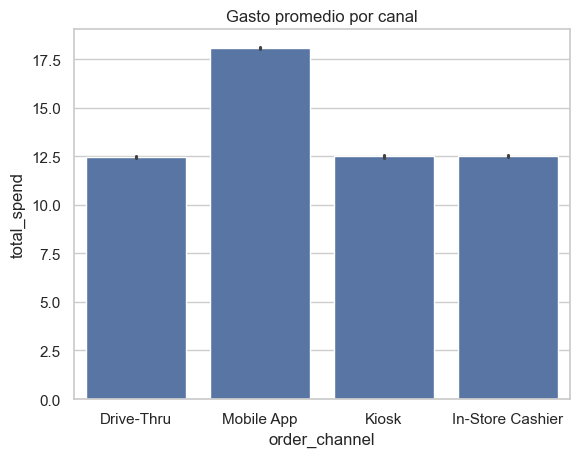

In [29]:
# Muestro un grafico de barras del gasto promedio por canal de pedido
sns.barplot(x='order_channel', y='total_spend', data=df)
plt.title('Gasto promedio por canal')
plt.show()

## Satisfacción promedio por canal de pedido (Gráfico)

El gráfico muestra cómo varía la satisfacción de los clientes según el canal utilizado:

- **Drive-Thru:** satisfacción más baja (~3.44).  
- **In-Store Cashier:** satisfacción intermedia (~3.70).  
- **Kiosk:** satisfacción moderada (~3.60).  
- **Mobile App:** satisfacción más alta (~3.86).

**Interpretación:**  
La visualización confirma que el canal digital (Mobile App) ofrece la mejor experiencia percibida por los clientes, mientras que el Drive-Thru presenta la menor satisfacción.  
Los canales físicos dentro de la tienda se ubican en un nivel intermedio, reflejando una experiencia aceptable pero con margen de mejora.

**Conclusión:**  
El gráfico refuerza la importancia de la experiencia digital como motor de satisfacción y fidelización.  
Al mismo tiempo, señala que el Drive-Thru es el canal con mayor oportunidad de mejora en términos de rapidez y calidad de atención.

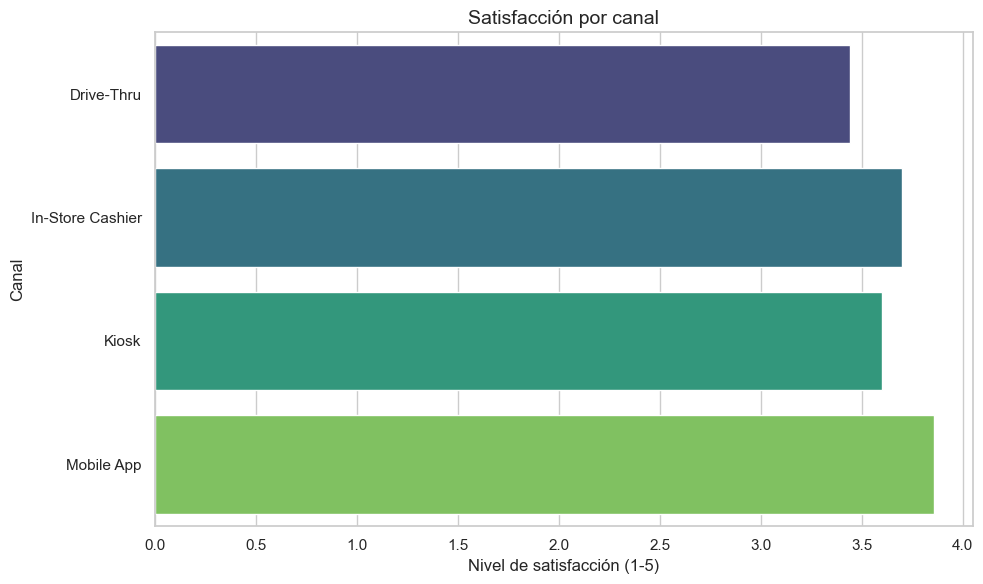

In [30]:
# Grafico la satisfacción promedio de clientes por canal de pedido
plot_category_values(
    df.groupby('order_channel')['customer_satisfaction'].mean(),
    title="Satisfacción por canal",
    xlabel="Nivel de satisfacción (1-5)",
    ylabel="Canal"
)

## Tiempo promedio de preparación por canal de pedido (Gráfico)

El gráfico muestra cómo varía el tiempo de cumplimiento según el canal de compra:

- **Drive-Thru:** ~5.8 minutos, el más lento.  
- **In-Store Cashier:** ~3.2 minutos, el más rápido.  
- **Kiosk:** ~4.0 minutos, intermedio.  
- **Mobile App:** ~4.5 minutos, también intermedio.

**Interpretación:**  
La visualización confirma que el **Drive-Thru** es el canal menos eficiente en términos de tiempo, mientras que la atención en caja dentro de la tienda es la más rápida.  
Los canales digitales y de autoservicio (Mobile App y Kiosk) se ubican en un punto medio, ofreciendo un buen equilibrio entre comodidad y rapidez.

**Conclusión:**  
Optimizar el Drive-Thru es clave para mejorar la experiencia del cliente y elevar la satisfacción.  
La atención en caja se destaca por su eficiencia, mientras que los canales digitales mantienen tiempos razonables que, combinados con mayor gasto y satisfacción, refuerzan su valor estratégico.

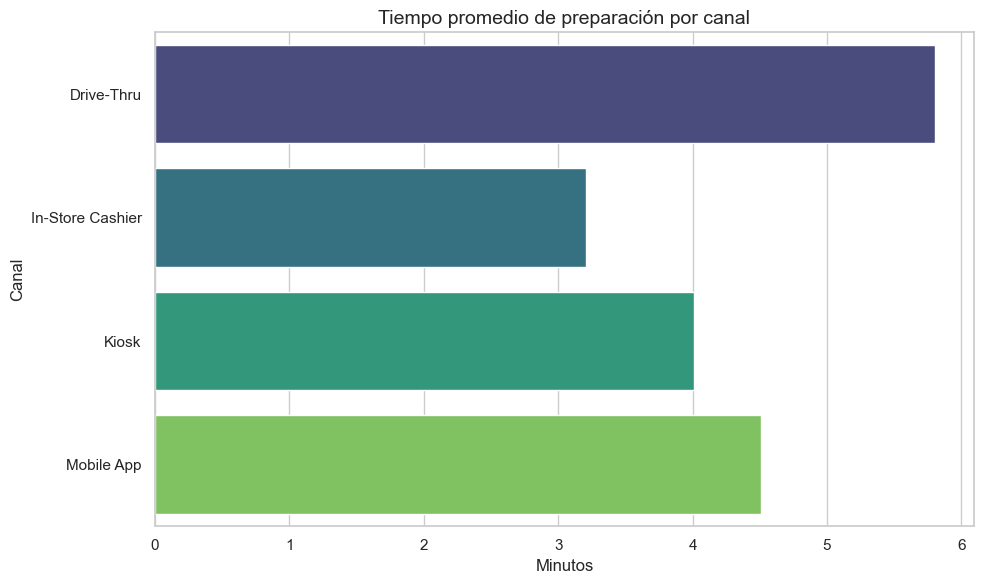

In [31]:
# Grafico el tiempo promedio de preparación por canal de pedido
plot_category_values(
    df.groupby('order_channel')['fulfillment_time_min'].mean(),
    title="Tiempo promedio de preparación por canal",
    xlabel="Minutos",
    ylabel="Canal"
)

## Distribución del gasto por membresía en el programa de recompensas (Boxplot)

El gráfico compara el gasto total de clientes **miembros** y **no miembros** del programa de recompensas:

- **Clientes miembros:**  
  - Presentan un gasto promedio más alto.  
  - La caja del boxplot está desplazada hacia valores superiores, lo que indica que la mayoría de sus compras son más grandes.  
  - Se observan más outliers en la parte superior, reflejando pedidos muy elevados.

- **Clientes no miembros:**  
  - Su gasto está más concentrado en valores moderados.  
  - La caja del boxplot es más baja y menos dispersa, lo que indica compras más homogéneas y menos casos extremos.  

**Interpretación:**  
El gráfico deja claro que pertenecer al programa de recompensas está asociado a un mayor gasto y a una mayor variabilidad en los montos.  
Los miembros tienden a realizar compras más grandes y ocasionalmente muy elevadas, mientras que los no miembros mantienen un patrón más estable y moderado.

**Conclusión:**  
El programa de recompensas cumple un rol estratégico en **incrementar el ticket promedio** y fomentar consumos más altos.  
Los clientes fidelizados representan un segmento valioso que conviene seguir incentivando con beneficios exclusivos y promociones.

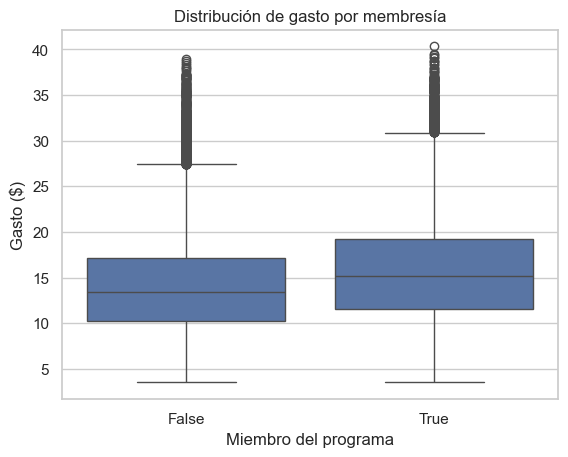

In [32]:
# Muestra la distribución del gasto según si el cliente es miembro del programa de recompensas
sns.boxplot(
    x='is_rewards_member',
    y='total_spend',
    data=df
)

plt.title('Distribución de gasto por membresía')
plt.xlabel('Miembro del programa')
plt.ylabel('Gasto ($)')
plt.show()

## Distribución de satisfacción según membresía (Tabla cruzada)

Se construyó una tabla cruzada normalizada para comparar la distribución de niveles de satisfacción entre clientes **miembros** y **no miembros** del programa de recompensas.

**Interpretación:**
- La tabla muestra, para cada nivel de satisfacción (1 a 5), qué proporción corresponde a miembros y no miembros.  
- Esto permite ver si los clientes fidelizados tienden a concentrarse en niveles más altos de satisfacción.  
- Si la columna de miembros presenta mayor proporción en niveles 4 y 5, significa que la membresía está asociada a una mejor experiencia percibida.  
- En cambio, si los no miembros tienen mayor proporción en niveles bajos (1–2), se confirma que la fidelización mejora la satisfacción.

**Conclusión:**
Este análisis complementa el boxplot de gasto por membresía: no solo los miembros gastan más, sino que también muestran una tendencia a estar más satisfechos.  
La membresía en el programa de recompensas se consolida como un factor positivo tanto en el **ticket promedio** como en la **percepción de calidad del servicio**.

In [33]:
# Creo una tabla cruzada normalizada para ver la distribución de satisfacción según membresía
pivot = pd.crosstab(
    df['customer_satisfaction'],
    df['is_rewards_member'],
    normalize='columns'
)

## Distribución de satisfacción por membresía (Heatmap)

El gráfico muestra la proporción de clientes en cada nivel de satisfacción (1 a 5), diferenciando entre **miembros** y **no miembros** del programa de recompensas:

- El color indica la intensidad de la proporción: valores más altos aparecen en tonos cálidos (rojo), mientras que los más bajos en tonos fríos (azul).  
- El mayor valor se observa en el nivel **4 de satisfacción**, tanto para miembros como para no miembros (~0.35).  
- Los clientes **miembros** tienden a concentrarse más en niveles altos de satisfacción (4 y 5).  
- Los **no miembros** muestran una distribución más dispersa, con mayor presencia en niveles bajos (1 y 2).

**Interpretación:**  
El heatmap confirma que la membresía en el programa de recompensas está asociada a una mejor experiencia percibida.  
Los clientes fidelizados no solo gastan más (como vimos en el boxplot), sino que también reportan niveles de satisfacción más altos.  
Los no miembros, en cambio, presentan mayor proporción en niveles bajos, lo que sugiere que la falta de beneficios puede impactar negativamente en su percepción.

**Conclusión:**  
La membresía en el programa de recompensas es un factor clave para mejorar tanto el **ticket promedio** como la **satisfacción del cliente**.  
Este hallazgo refuerza la importancia de invertir en estrategias de fidelización y beneficios exclusivos.

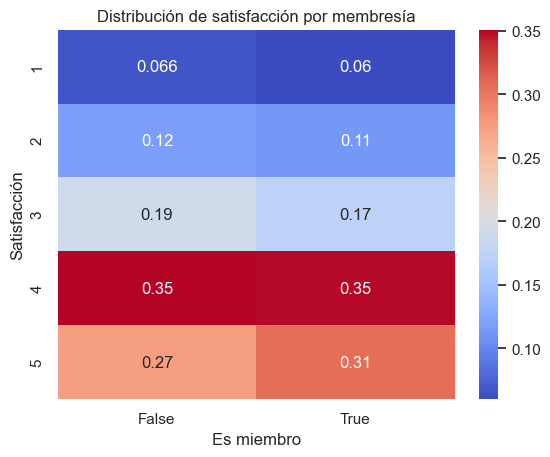

In [34]:
# Muestro un heatmap para visualizar la relación entre satisfacción y membresía
sns.heatmap(pivot, annot=True, cmap='coolwarm')

plt.title('Distribución de satisfacción por membresía')
plt.xlabel('Es miembro')
plt.ylabel('Satisfacción')
plt.show()

## Tiempo promedio de preparación por membresía (Gráfico)

El gráfico compara el tiempo promedio de cumplimiento entre clientes **miembros** y **no miembros** del programa de recompensas:

- Ambos grupos presentan tiempos muy similares, alrededor de **4.5 minutos**.  
- No se observa una diferencia significativa en la rapidez del servicio entre miembros y no miembros.  
- Esto indica que la membresía no influye directamente en la eficiencia operativa del proceso de preparación.

**Interpretación:**  
La membresía está asociada a un mayor gasto y a una mayor satisfacción, pero no afecta los tiempos de cumplimiento.  
Esto sugiere que los beneficios del programa se relacionan más con la **percepción del cliente** y el **comportamiento de compra**, que con la logística interna.

**Conclusión:**  
El programa de recompensas es un motor de fidelización y consumo, pero la eficiencia operativa se mantiene estable para todos los clientes.  
La mejora de tiempos depende de la gestión del canal (Drive-Thru, App, Kiosk, Cashier), no de la membresía.

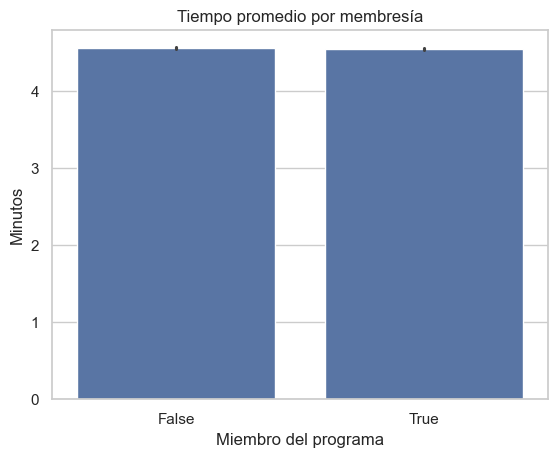

In [35]:
# Muestro el tiempo promedio de preparación según si el cliente es miembro del programa
sns.barplot(
    x='is_rewards_member',
    y='fulfillment_time_min',
    data=df
)

plt.title('Tiempo promedio por membresía')
plt.xlabel('Miembro del programa')
plt.ylabel('Minutos')
plt.show()

## Gasto promedio por tamaño de carrito (Gráfico)

El gráfico muestra el gasto promedio en función de la cantidad de ítems en el pedido:

- A medida que aumenta el tamaño del carrito (de 3 a 10 ítems), el gasto promedio también se incrementa de forma consistente.  
- Los carritos más pequeños (3–4 ítems) se ubican en torno a **11–13 dólares**.  
- Los carritos medianos (6–7 ítems) alcanzan valores cercanos a **16–18 dólares**.  
- Los carritos grandes (9–10 ítems) superan los **20 dólares** en promedio.

**Interpretación:**  
La relación entre tamaño del carrito y gasto es prácticamente lineal: más ítems implican mayor ticket promedio.  
Esto refleja un patrón de consumo lógico y confirma que los pedidos grandes son un segmento clave para la rentabilidad.

**Conclusión:**  
El tamaño del carrito es un factor determinante en el gasto total.  
Los clientes que realizan pedidos grandes representan un grupo valioso que conviene incentivar con promociones específicas (ejemplo: descuentos por cantidad o combos).  
Este hallazgo complementa el análisis de outliers: los pedidos con gasto elevado corresponden justamente a carritos grandes y personalizados.

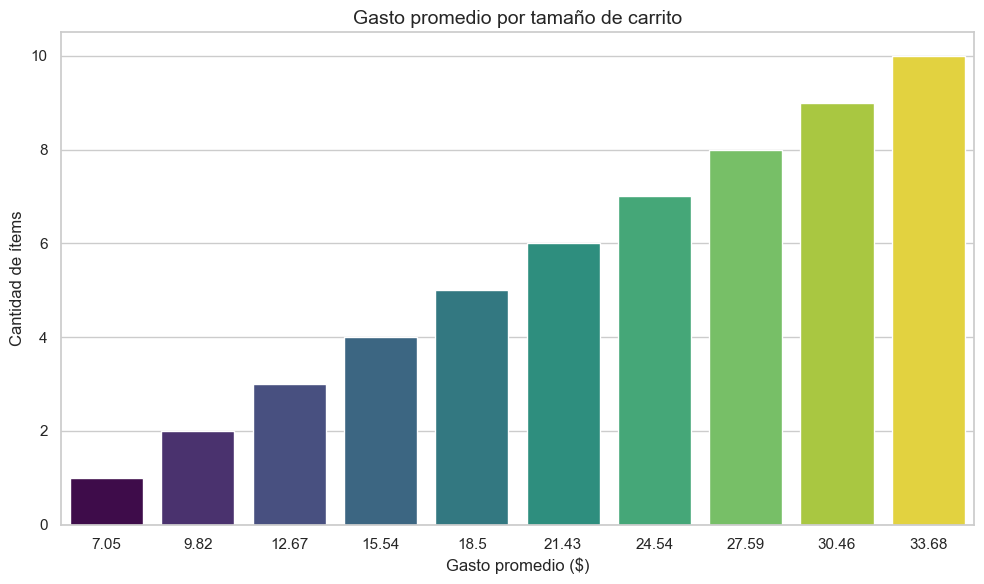

In [36]:
# Grafico el gasto promedio según el tamaño del carrito
plot_category_values(
    df.groupby('cart_size')['total_spend'].mean().round(2),
    title="Gasto promedio por tamaño de carrito",
    xlabel="Gasto promedio ($)",
    ylabel="Cantidad de ítems"
)

## Satisfacción promedio por tamaño de carrito (Gráfico)

El gráfico muestra cómo varía la satisfacción de los clientes en función de la cantidad de ítems en el pedido:

- Los carritos más pequeños (3–4 ítems) presentan niveles de satisfacción más bajos (~3.3–3.5).  
- A medida que aumenta el tamaño del carrito, la satisfacción también crece, alcanzando valores cercanos a **4.0–4.1** en carritos medianos (6–7 ítems).  
- Los carritos grandes (8–10 ítems) muestran la satisfacción más alta, con picos cercanos a **4.2–4.3**.  
- En algunos casos, la satisfacción tiende a estabilizarse o incluso descender levemente en los carritos más grandes, lo que puede reflejar la complejidad de pedidos muy grandes.

**Interpretación:**  
Existe una relación positiva entre el tamaño del carrito y la satisfacción del cliente: quienes realizan pedidos más grandes suelen estar más satisfechos.  
Esto puede deberse a que los clientes que agregan más ítems aprovechan mejor la experiencia de compra, personalizan más sus pedidos o perciben mayor valor en la transacción.

**Conclusión:**  
El tamaño del carrito no solo impacta en el gasto total, sino también en la satisfacción.  
Los clientes con pedidos grandes representan un segmento estratégico: gastan más y reportan mayor satisfacción, lo que los convierte en un grupo clave para fidelización y promociones específicas.

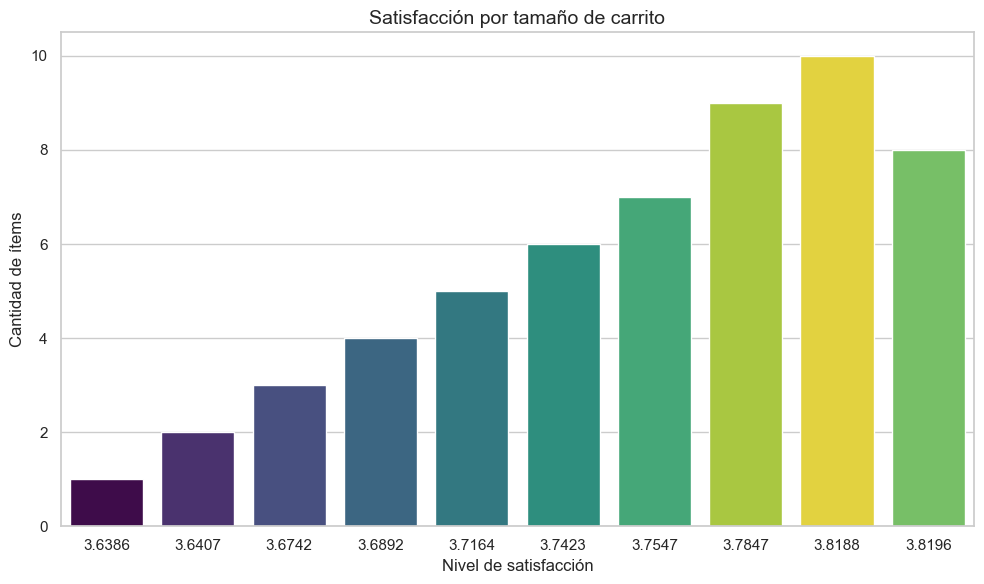

In [37]:
# Grafico la satisfacción promedio según el tamaño del carrito
plot_category_values(
    df.groupby('cart_size')['customer_satisfaction'].mean().round(4),
    title="Satisfacción por tamaño de carrito",
    xlabel="Nivel de satisfacción",
    ylabel="Cantidad de ítems"
)

## Relación entre tamaño de carrito y gasto total (Scatterplot)

El gráfico muestra cómo varía el gasto total en función de la cantidad de ítems en el carrito:

- Se observa una clara tendencia ascendente: a mayor cantidad de ítems, mayor gasto total.  
- Los puntos se distribuyen en forma creciente, confirmando la relación positiva entre tamaño del carrito y ticket promedio.  
- Los pedidos grandes (carritos con más ítems) concentran los valores más altos de gasto, incluyendo los outliers identificados previamente.  
- La dispersión refleja que, aunque el gasto aumenta con el tamaño del carrito, existe variabilidad en cada nivel (no todos los carritos de 6 ítems cuestan lo mismo, por ejemplo).

**Interpretación:**  
El scatterplot confirma que el **tamaño del carrito es un factor determinante en el gasto total**.  
Los clientes que realizan pedidos grandes tienden a gastar más y, como vimos en el análisis anterior, también reportan mayor satisfacción.  
Esto refuerza la idea de que los pedidos grandes son un segmento estratégico para la rentabilidad.

**Conclusión:**  
La relación entre tamaño del carrito y gasto es consistente y positiva.  
Los clientes con carritos grandes representan un grupo clave para promociones, combos y estrategias de fidelización, ya que combinan **alto gasto** con **alta satisfacción**.

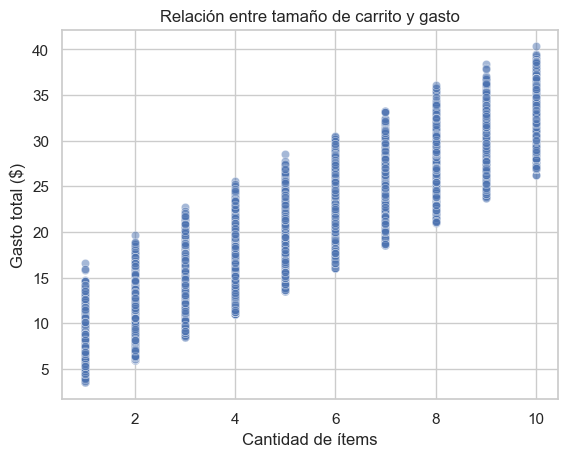

In [38]:
# Muestro la relación entre el tamaño del carrito y el gasto total
sns.scatterplot(
    x='cart_size',
    y='total_spend',
    data=df,
    alpha=0.5
)

plt.title('Relación entre tamaño de carrito y gasto')
plt.xlabel('Cantidad de ítems')
plt.ylabel('Gasto total ($)')
plt.show()

# Resumen Ejecutivo del EDA
- Los clientes más valiosos usan la **Mobile App**, son miembros del programa de recompensas y realizan compras grandes.  
- El **Drive-Thru** muestra el peor desempeño (tiempos más largos y menor satisfacción).  
- La membresía en recompensas aumenta el ticket promedio y la percepción positiva, aunque no impacta en los tiempos de preparación.  
- La operación es eficiente en general: los pedidos grandes incluyen tanto outliers de alto gasto como altos niveles de satisfacción.  

**Conclusión:**  
Estos hallazgos respaldan el modelado predictivo y sugieren estrategias de negocio enfocadas en fidelización, optimización de canales y promoción de carritos grandes.

---

# Selección de variables para modelado

Tras el EDA se definieron las variables relevantes para el modelo predictivo:

## Features
- order_channel  
- cart_size  
- num_customizations  
- fulfillment_time_min  
- has_food_item  
- order_ahead  
- is_rewards_member  

## Target
- total_spend  

**Interpretación:**  
Las variables reflejan aspectos operativos y de comportamiento del cliente.  
El objetivo es predecir el **gasto total** y entender qué factores impulsan el ticket promedio.

In [39]:
#Seleccion de variables
features = [
    'order_channel',
    'cart_size',
    'num_customizations',
    'fulfillment_time_min',
    'has_food_item',
    'order_ahead',
    'is_rewards_member'
]

target = 'total_spend'

# Creación del dataset para modelado

Se genera un nuevo DataFrame (`df_model`) que contiene únicamente las variables seleccionadas (*features*) y la variable objetivo (*target*).  
Este dataset será la base para el entrenamiento y evaluación de los modelos.

In [40]:
# Creo un nuevo DataFrame solo con las variables necesarias para el modelo
df_model = df[features + [target]].copy()

# One-hot encoding

Se transforman las variables categóricas en variables numéricas mediante **one-hot encoding**, utilizando `pd.get_dummies` con `drop_first=True` para evitar multicolinealidad.  
El DataFrame `df_model` queda listo para las siguientes etapas del pipeline de modelado.

In [41]:
# Convierte variables categóricas en variables numéricas (one-hot encoding)
df_model = pd.get_dummies(df_model, drop_first=True)

# División en entrenamiento y prueba

Se separa el dataset en variables predictoras (**X**) y objetivo (**y**), y luego se divide en conjuntos de entrenamiento (80%) y prueba (20%) utilizando `train_test_split`.  
Esto permite entrenar el modelo con una parte de los datos y evaluar su desempeño con datos nunca vistos, asegurando una validación más confiable.

In [42]:
# Divide los datos en entrenamiento y prueba (80% / 20%)
# Separo los datos en variables predictoras (X) y objetivo (y)
from sklearn.model_selection import train_test_split

X = df_model.drop('total_spend', axis=1)
y = df_model['total_spend']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entrenamiento del modelo

Se entrena un modelo de **Random Forest Regressor** para predecir el gasto total (`total_spend`).  
El modelo se ajusta con los datos de entrenamiento (`X_train`, `y_train`) y servirá como base para evaluar desempeño y comparar con otros algoritmos.

In [43]:
# Entrena un modelo Random Forest para predecir el gasto total
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

# Predicciones del modelo

Se generan las predicciones sobre el conjunto de prueba (`X_test`) y se almacenan en `y_pred`.  
Estas predicciones serán utilizadas para evaluar el rendimiento del modelo frente a los datos reales (`y_test`).

In [44]:
# Genera las predicciones del modelo sobre el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluación del modelo

Se calculan métricas de desempeño sobre el conjunto de prueba:

- **RMSE (Root Mean Squared Error):** 1.02 → el error promedio es bajo y fácil de interpretar en la escala del gasto.  
- **R² (Coeficiente de determinación):** 0.97 → el modelo explica el 97% de la variabilidad del gasto total.

**Conclusión:**  
El modelo de Random Forest muestra un excelente ajuste, con alta capacidad explicativa y bajo error.  
Estos resultados lo convierten en una base sólida para predecir el gasto total y explorar mejoras adicionales.

In [45]:
# Calcula métricas de evaluación del modelo (RMSE y R²)
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)  # error cuadratico medio
rmse = np.sqrt(mse)                       # raiz del error (mas interpretable)
r2 = r2_score(y_test, y_pred)             # que tan bien explica el modelo

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

RMSE: 1.02
R²: 0.97


# Importancia de variables

El modelo de Random Forest identifica las variables más influyentes en el gasto total:  

- **cart_size** como factor principal.  
- **order_channel (Mobile App)** y **num_customizations** como secundarios relevantes.  
- El resto de las variables aportan información complementaria con menor impacto.  

**Conclusión:**  
El tamaño del carrito domina la explicación del gasto, seguido por el canal de pedido y las personalizaciones.

In [46]:
# Calcula y ordena la importancia de las variables del modelo, y muetro las 10 variables mas importantes
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)
importances.head(10)

cart_size                         0.811329
order_channel_Mobile App          0.102208
num_customizations                0.054648
has_food_item                     0.018605
fulfillment_time_min              0.009729
is_rewards_member                 0.001702
order_ahead                       0.000935
order_channel_In-Store Cashier    0.000435
order_channel_Kiosk               0.000409
dtype: float64

# Visualización de importancia de variables

Se muestra un gráfico con las 10 variables más importantes en la predicción del gasto según el modelo de Random Forest.  
El resultado confirma que:

- **cart_size** es, por lejos, la variable más determinante.  
- Le siguen **order_channel (Mobile App)** y **num_customizations** como factores relevantes.  
- El resto de las variables aportan información secundaria.

**Conclusión:**  
El tamaño del carrito domina la explicación del gasto, mientras que el canal de pedido y las personalizaciones refuerzan el modelo.  
Esta visualización facilita la interpretación y comunicación de los resultados a nivel estratégico.

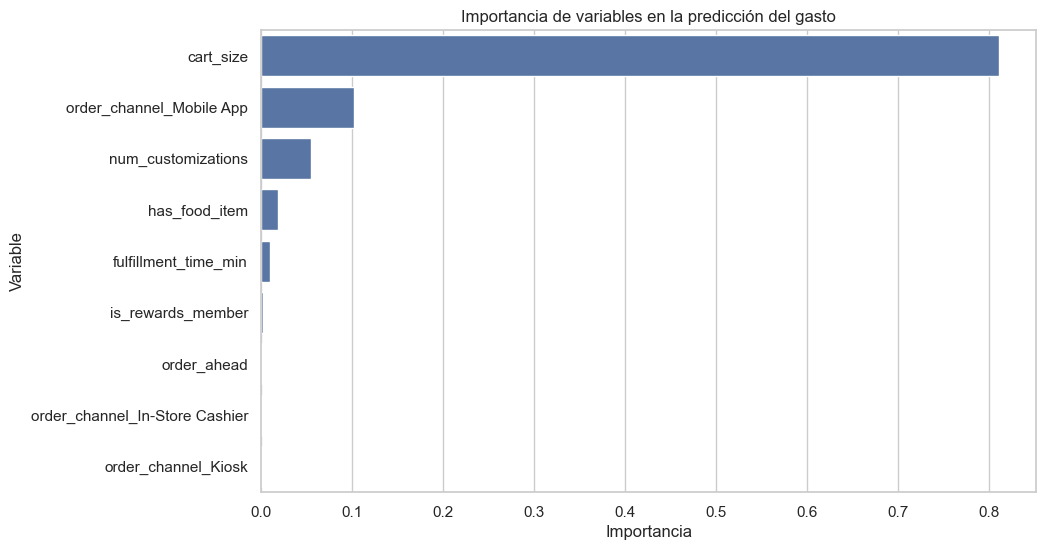

In [47]:
# Muestro un grafico de las 10 variables más importantes del modelo
plt.figure(figsize=(10,6))

sns.barplot(
    x=importances.head(10),
    y=importances.head(10).index
)

plt.title('Importancia de variables en la predicción del gasto')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

# Conclusión final del trabajo

El análisis exploratorio permitió identificar patrones claros de consumo y operación:  
los clientes más valiosos son quienes usan la **Mobile App**, son **miembros del programa de recompensas** y realizan **carritos grandes**, mientras que el **Drive-Thru** aparece como el canal con mayor oportunidad de mejora.

El modelo de **Random Forest Regressor** alcanzó un desempeño excelente (R²=0.97, RMSE=1.02), confirmando que el **tamaño del carrito** es el principal factor que explica el gasto total, seguido por el canal de pedido y las personalizaciones.

**Conclusión estratégica:**  
El trabajo demuestra que es posible predecir el gasto total con alta precisión y que las variables más influyentes están directamente ligadas a la experiencia del cliente.  
Esto ofrece una base sólida para diseñar estrategias de negocio enfocadas en **fidelización, optimización de canales y promoción de carritos grandes**.